# Drug Efficacy Dataset for Asthma: Data Understanding and Initial Exploration

## Project Overview

In this project, I am working with a drug efficacy dataset related to asthma patients. The main outcome of interest is `post_index_exacerbations365`, which represents the number of asthma exacerbations during the first year after starting therapy.

The goal of this project is to build an end-to-end machine learning workflow that can help predict asthma-related outcomes using pre-index clinical and claims-based patient information. Before building any model, I first need to understand the dataset carefully, check the structure of the variables, identify possible data quality problems, and think about what kind of modeling approach may be appropriate.

This notebook focuses on the first stage of the project: data loading, initial inspection, and basic understanding of the dataset.


## Initial Questions Before Modeling

Before starting machine learning modeling, I want to answer a few basic questions about the dataset:

1. How many rows and columns are present in the dataset?
2. What are the input features and what is the target variable?
3. Are there missing values or duplicate records?
4. What are the data types of the variables?
5. Are the variables mostly binary, continuous, or count-based?
6. What does the outcome variable `post_index_exacerbations365` look like?
7. Should this problem be treated as a regression problem, a count prediction problem, or possibly a classification problem?

These questions will help me decide the next steps for exploratory data analysis and modeling.

In [1]:
# Basic libraries for data handling and exploration
import pandas as pd
import numpy as np

# Display settings to make notebook output easier to read
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

## Loading the Dataset

The dataset was downloaded from Kaggle and saved inside the `data/raw/` folder. I am keeping the original raw data unchanged so that the project remains reproducible. Any cleaned or processed versions of the data will be saved later in the `data/processed/` folder.

In [2]:
# Define the relative file path
data_path = "../data/raw/DrugEfficacyDataset.csv"

# Read the dataset
df = pd.read_csv(data_path)

# Display the first few rows
df.head()

,patid,index_age,previous_asthma_drugs,total_pre_index_cannisters_365,post_index_exacerbations365,pneumonia,sinusitis,acute_bronchitis,acute_laryngitis,upper_respiratory_infection,gerd,rhinitis,adherence,total_pre_index_charge,pre_asthma_days,pre_asthma_charge,pre_asthma_pharma_charge,drug_s,female,log_charges,log_asthma_charge
0,1073754155,14,1,1,0,0,0,1,0,1,0,0,0.0845,1224.7675,1,314.0000,218.1300,0,0,7.1105,5.3851
1,1073799394,21,1,2,2,0,1,1,0,0,0,1,0.0845,20290.5343,0,0.0000,44.9800,0,0,9.9179,3.8062
2,1073854918,62,1,0,0,0,0,0,0,0,0,0,0.7384,2964.2542,4,480.0000,99.2600,0,0,7.9944,4.5977
3,1073898249,30,1,2,0,0,0,1,0,1,0,0,0.0845,3223.7088,0,0.0000,59.5800,0,1,8.0783,4.0873
4,1073913003,40,1,1,0,0,1,0,1,1,0,1,0.5068,1287.2544,2,689.0000,29.7900,0,0,7.1603,3.3942


## First Look at the Dataset

After loading the dataset, I will first check the shape of the data and preview the first few rows. This gives me an initial idea of how many patient records and variables are available, and whether the columns were read correctly.

In [3]:
# Check number of rows and columns
df.shape

(18215, 21)

In [4]:
# Display all column names
df.columns.tolist()

['patid',
 'index_age',
 'previous_asthma_drugs',
 'total_pre_index_cannisters_365',
 'post_index_exacerbations365',
 'pneumonia',
 'sinusitis',
 'acute_bronchitis',
 'acute_laryngitis',
 'upper_respiratory_infection',
 'gerd',
 'rhinitis',
 'adherence',
 'total_pre_index_charge',
 'pre_asthma_days',
 'pre_asthma_charge',
 'pre_asthma_pharma_charge',
 'drug_s',
 'female',
 'log_charges',
 'log_asthma_charge']

In [5]:
# Check data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18215 entries, 0 to 18214
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patid                           18215 non-null  int64  
 1   index_age                       18215 non-null  int64  
 2   previous_asthma_drugs           18215 non-null  int64  
 3   total_pre_index_cannisters_365  18215 non-null  int64  
 4   post_index_exacerbations365     18215 non-null  int64  
 5   pneumonia                       18215 non-null  int64  
 6   sinusitis                       18215 non-null  int64  
 7   acute_bronchitis                18215 non-null  int64  
 8   acute_laryngitis                18215 non-null  int64  
 9   upper_respiratory_infection     18215 non-null  int64  
 10  gerd                            18215 non-null  int64  
 11  rhinitis                        18215 non-null  int64  
 12  adherence                       18215 non-n

## Initial Dataset Structure Observation

The dataset contains **18,215 patient records** and **21 columns**. Each row appears to represent one asthma patient, and the columns include demographic information, prior asthma-related drug/treatment history, diagnosis indicators, healthcare charge variables, medication adherence, drug group assignment, and the post-index outcome.

The target variable is:

- `post_index_exacerbations365`

This variable represents the number of asthma exacerbations during the year after initiating therapy. Since the values are non-negative counts, this may not be a simple continuous regression problem. It may require thinking about count-based modeling, regression modeling, or converting the outcome into a binary classification problem later.

At this stage, I will not decide the final modeling approach yet. First, I need to better understand the variable types, data quality, and outcome distribution.

In [6]:
# To display a few random rows to get a broader sense of the data
df.sample(5, random_state=22)

,patid,index_age,previous_asthma_drugs,total_pre_index_cannisters_365,post_index_exacerbations365,pneumonia,sinusitis,acute_bronchitis,acute_laryngitis,upper_respiratory_infection,gerd,rhinitis,adherence,total_pre_index_charge,pre_asthma_days,pre_asthma_charge,pre_asthma_pharma_charge,drug_s,female,log_charges,log_asthma_charge
16113,1215780903,53,1,0,0,0,0,0,0,0,0,1,0.3760,1433.0595,1,227.0000,845.7000,1,0,7.2676,6.7402
1585,1125859796,33,1,1,0,0,1,1,0,1,0,1,0.0845,1427.5297,3,510.0000,54.3900,0,1,7.2637,3.9962
12535,1505760435,44,1,0,0,0,1,0,0,0,0,1,0.2534,8722.6079,4,885.0000,173.3000,0,0,9.0737,5.1550
4609,1202872464,47,1,0,0,0,1,1,0,0,0,0,0.0845,26599.7906,0,0.0000,98.4000,0,1,10.1887,4.5890
566,1092017818,48,1,1,0,0,0,0,0,0,0,0,0.5068,8027.5014,1,70.0000,22.4800,0,1,8.9906,3.1126


In [7]:
# To check summary statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
patid,18215.0000,1317072654.2669,154570755.9664,1073754155.0000,1183442347.5000,1282388763.0000,1493698756.5000,1771898675.0000
index_age,18215.0000,38.3046,15.2182,12.0000,26.0000,41.0000,50.0000,65.0000
previous_asthma_drugs,18215.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
total_pre_index_cannisters_365,18215.0000,0.7937,0.7235,0.0000,0.0000,1.0000,1.0000,2.0000
post_index_exacerbations365,18215.0000,0.1746,0.6333,0.0000,0.0000,0.0000,0.0000,14.0000
pneumonia,18215.0000,0.0502,0.2184,0.0000,0.0000,0.0000,0.0000,1.0000
sinusitis,18215.0000,0.3197,0.4664,0.0000,0.0000,0.0000,1.0000,1.0000
acute_bronchitis,18215.0000,0.2605,0.4389,0.0000,0.0000,0.0000,1.0000,1.0000
acute_laryngitis,18215.0000,0.0169,0.1287,0.0000,0.0000,0.0000,0.0000,1.0000
upper_respiratory_infection,18215.0000,0.2217,0.4154,0.0000,0.0000,0.0000,0.0000,1.0000


## Important First Observations from `df.info()` and `df.describe()`

From the initial inspection, I observed the following:

1. There are **no missing values** based on the non-null counts.
2. All columns are numeric, which is convenient for machine learning modeling.
3. The column `patid` appears to be a patient identifier and should not be used as a predictive feature.
4. The column `previous_asthma_drugs` has the same value for every patient, so it may not provide useful predictive information.
5. Several variables are binary indicator variables, such as `pneumonia`, `sinusitis`, `acute_bronchitis`, `female`, and `drug_s`.
6. The outcome variable `post_index_exacerbations365` has a mean of about **0.17**, a median of **0**, and a maximum of **14**. This suggests that most patients had no exacerbation after treatment, while a small number had multiple exacerbations.
7. The charge-related variables are highly skewed. For example, `total_pre_index_charge` has a median around **3,155** but a maximum above **875,000**. This suggests the presence of extreme high-cost patients.
8. The dataset already includes log-transformed charge variables: `log_charges` and `log_asthma_charge`, which may be more useful for modeling than the original skewed charge variables.

In [8]:
# To check missing values in each column
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

patid                             0
index_age                         0
previous_asthma_drugs             0
total_pre_index_cannisters_365    0
post_index_exacerbations365       0
pneumonia                         0
sinusitis                         0
acute_bronchitis                  0
acute_laryngitis                  0
upper_respiratory_infection       0
gerd                              0
rhinitis                          0
adherence                         0
total_pre_index_charge            0
pre_asthma_days                   0
pre_asthma_charge                 0
pre_asthma_pharma_charge          0
drug_s                            0
female                            0
log_charges                       0
log_asthma_charge                 0
dtype: int64

In [9]:
# Check missing value percentage
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percent": missing_percent
})

missing_summary

,missing_count,missing_percent
patid,0,0.0000
index_age,0,0.0000
previous_asthma_drugs,0,0.0000
total_pre_index_cannisters_365,0,0.0000
post_index_exacerbations365,0,0.0000
pneumonia,0,0.0000
sinusitis,0,0.0000
acute_bronchitis,0,0.0000
acute_laryngitis,0,0.0000
upper_respiratory_infection,0,0.0000


## Missing Value Observation

Based on the initial missing value check, the dataset does not appear to have missing values. This is helpful because I may not need imputation at this stage.

However, I should still be careful because some values may be coded as zero even when they represent absence of service use or no recorded charge. For example, `pre_asthma_charge` has a minimum value of 0, which may be meaningful rather than missing.

In [10]:
# To check number of duplicated rows
duplicate_count = df.duplicated().sum()

duplicate_count

np.int64(0)

In [11]:
# Lets check whether patient IDs are unique
unique_patients = df["patid"].nunique()
total_rows = df.shape[0]

print("Total rows:", total_rows)
print("Unique patient IDs:", unique_patients)
print("Duplicate patient IDs:", total_rows - unique_patients)

Total rows: 18215
Unique patient IDs: 18215
Duplicate patient IDs: 0



## Duplicate and Patient ID Observation

The dataset contains **0 fully duplicated rows**. The number of unique patient IDs is also **18,215**, which is the same as the total number of rows.

This suggests that each row likely represents one unique patient. Therefore, there is no immediate need to remove duplicate records.

The `patid` column should still not be used as a predictive feature because it is only an identifier. Including patient ID in a machine learning model could introduce noise or artificial patterns that do not have clinical meaning.

In [12]:
# Check number of unique values in each column
unique_counts = df.nunique().sort_values()

unique_counts

previous_asthma_drugs                 1
acute_bronchitis                      2
sinusitis                             2
pneumonia                             2
rhinitis                              2
gerd                                  2
upper_respiratory_infection           2
acute_laryngitis                      2
female                                2
drug_s                                2
total_pre_index_cannisters_365        3
post_index_exacerbations365          14
pre_asthma_days                      46
index_age                            54
adherence                           353
pre_asthma_charge                  3946
pre_asthma_pharma_charge           8375
log_asthma_charge                  8375
log_charges                       17968
total_pre_index_charge            17968
patid                             18215
dtype: int64


## Unique Value Observation

The number of unique values helps me understand which variables are binary, count-based, continuous, or not useful for modeling.

One important observation is that `previous_asthma_drugs` has only **1 unique value**. This means every patient has the same value for this variable. Since it does not vary across patients, it cannot help the model explain differences in the outcome. I will likely remove this variable before modeling.

Several variables have only **2 unique values**, such as `pneumonia`, `sinusitis`, `acute_bronchitis`, `female`, and `drug_s`. These are binary indicator variables.

The variable `total_pre_index_cannisters_365` has **3 unique values**, suggesting that it is a small discrete count variable. This represents the number of SABA rescue inhaler canisters used in the year before treatment start. Higher SABA use may indicate worse asthma control before treatment.

The charge-related variables have many unique values and appear to be continuous. These variables may need special attention because the earlier summary statistics showed strong skewness and very large maximum values.

In [13]:
# Grouping Variables by Type
# Define target and ID columns
target_col = "post_index_exacerbations365"
id_col = "patid"

# Binary indicator variables based on dataset description and summary statistics
binary_cols = [
    "pneumonia",
    "sinusitis",
    "acute_bronchitis",
    "acute_laryngitis",
    "upper_respiratory_infection",
    "gerd",
    "rhinitis",
    "drug_s",
    "female"
]

# Count / discrete numeric variables
count_cols = [
    "index_age",
    "previous_asthma_drugs",
    "total_pre_index_cannisters_365",
    "pre_asthma_days"
]

# Continuous charge and adherence variables
continuous_cols = [
    "adherence",
    "total_pre_index_charge",
    "pre_asthma_charge",
    "pre_asthma_pharma_charge",
    "log_charges",
    "log_asthma_charge"
]

print("Target column:", target_col)
print("ID column:", id_col)
print("Binary columns:", binary_cols)
print("Count/discrete columns:", count_cols)
print("Continuous columns:", continuous_cols)

Target column: post_index_exacerbations365
ID column: patid
Binary columns: ['pneumonia', 'sinusitis', 'acute_bronchitis', 'acute_laryngitis', 'upper_respiratory_infection', 'gerd', 'rhinitis', 'drug_s', 'female']
Count/discrete columns: ['index_age', 'previous_asthma_drugs', 'total_pre_index_cannisters_365', 'pre_asthma_days']
Continuous columns: ['adherence', 'total_pre_index_charge', 'pre_asthma_charge', 'pre_asthma_pharma_charge', 'log_charges', 'log_asthma_charge']



## Feature Grouping

To understand the dataset more clearly, I grouped the variables into different types:

- **Identifier variable:** `patid`
- **Target variable:** `post_index_exacerbations365`
- **Binary diagnosis or demographic variables:** pneumonia, sinusitis, bronchitis, laryngitis, respiratory infection, GERD, rhinitis, drug group, and sex
- **Discrete/count variables:** age, prior asthma drug indicator, number of rescue inhaler canisters, and number of pre-index asthma treatment days
- **Continuous variables:** adherence and healthcare charge-related variables

The variable `total_pre_index_cannisters_365` represents the number of SABA rescue inhaler canisters used during the year before treatment start. SABA stands for Short-Acting Beta Agonist, which is usually used for quick relief of asthma symptoms. More canister use may suggest more severe or poorly controlled asthma before the index date.

This grouping will help during exploratory data analysis because binary, count-based, and continuous variables need different types of summaries and visualizations.

In [14]:
# Summary of the target variable
df[target_col].describe()

count   18215.0000
mean        0.1746
std         0.6333
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0000
max        14.0000
Name: post_index_exacerbations365, dtype: float64

In [15]:
# Frequency of each exacerbation count
target_counts = df[target_col].value_counts().sort_index()

target_counts

post_index_exacerbations365
0     16124
1      1525
2       333
3       115
4        48
5        32
6        12
7         9
8         9
9         3
10        2
12        1
13        1
14        1
Name: count, dtype: int64

In [16]:
# Frequency and percentage of each exacerbation count
target_distribution = pd.DataFrame({
    "count": df[target_col].value_counts().sort_index(),
    "percent": df[target_col].value_counts(normalize=True).sort_index() * 100
})

target_distribution

,count,percent
post_index_exacerbations365,,
0,16124,88.5205
1,1525,8.3722
2,333,1.8282
3,115,0.6313
4,48,0.2635
5,32,0.1757
6,12,0.0659
7,9,0.0494
8,9,0.0494


In [17]:
# To check binary outcome count
# Create a binary version of the target:
# 0 = no exacerbation
# 1 = at least one exacerbation
df["had_exacerbation"] = (df[target_col] > 0).astype(int)

df["had_exacerbation"].value_counts()

had_exacerbation
0    16124
1     2091
Name: count, dtype: int64

In [20]:
# Percentage of patients with and without exacerbation
df["had_exacerbation"].value_counts(normalize=True) * 100

had_exacerbation
0   88.5205
1   11.4795
Name: proportion, dtype: float64

## Target Variable Distribution Observation

The outcome variable `post_index_exacerbations365` is a count variable. It records the number of asthma exacerbations during the year after initiating therapy.

The distribution is highly concentrated at zero:

- **16,124 patients** had 0 exacerbations.
- **2,091 patients** had at least 1 exacerbation.
- The maximum observed value is 14 exacerbations.

This means about **88.52%** of patients had no exacerbation, while only about **11.48%** had at least one exacerbation.
Although the maximum target value is 14, there are 14 unique observed outcome values because the value 11 does not appear in the dataset.

This is an important modeling issue. If I build a binary classification model, the classes will be imbalanced. A model could get high accuracy by mostly predicting “no exacerbation,” but that would not necessarily be clinically useful. Therefore, I will need to use better evaluation metrics later, such as recall, precision, F1-score, ROC-AUC, and PR-AUC.

For the original count outcome, the distribution also suggests that standard regression may not be ideal by itself because the target has many zeros and a long right tail. Later, I may compare different approaches, such as regression models, count-based models, and binary classification.


## Binary Outcome Idea

Although the original outcome is a count variable, I created a temporary binary outcome called `had_exacerbation` for exploration:

- `0`: No exacerbation during the post-index year
- `1`: At least one exacerbation during the post-index year

This binary version helps me look at the problem from a clinical risk perspective: which patients had at least one exacerbation after starting therapy?

This does not replace the original target variable. It is only created for exploration and may also be useful later for classification modeling. Later, I can decide whether the project should focus on count prediction, binary classification, or both.

# Exploratory Data Analysis: Target Variable

After checking the basic structure of the dataset, I want to explore the outcome variable visually. This is important because the modeling strategy depends heavily on the target distribution.

For this dataset, the target variable is a count outcome, but it is highly concentrated at zero. Therefore, I will first visualize:

1. The distribution of the original count outcome.
2. The distribution of the binary outcome.
3. The outcome distribution after excluding zero values, to better understand patients who had at least one exacerbation.

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a simple display style
sns.set_theme(style="whitegrid")

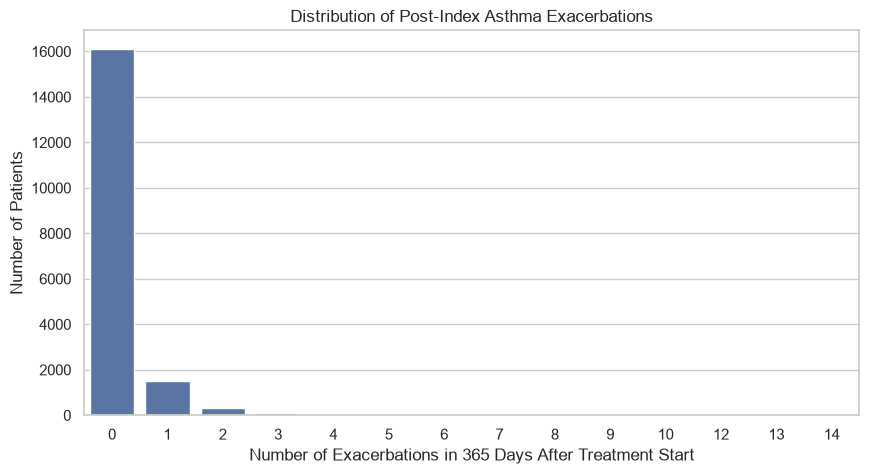

In [22]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x=target_col,
    order=sorted(df[target_col].unique())
)

plt.title("Distribution of Post-Index Asthma Exacerbations")
plt.xlabel("Number of Exacerbations in 365 Days After Treatment Start")
plt.ylabel("Number of Patients")
plt.show()

## Observation: Original Count Outcome

The bar plot shows that the target variable is strongly concentrated at zero. Most patients had no exacerbation during the year after initiating therapy.

Only a smaller group of patients had one or more exacerbations, and very few patients had high exacerbation counts such as 5 or more. This confirms that the outcome is zero-heavy and right-skewed.

This matters because a standard regression model may mostly learn to predict values close to zero. For this reason, I may need to compare multiple modeling approaches later instead of relying on one model type only.

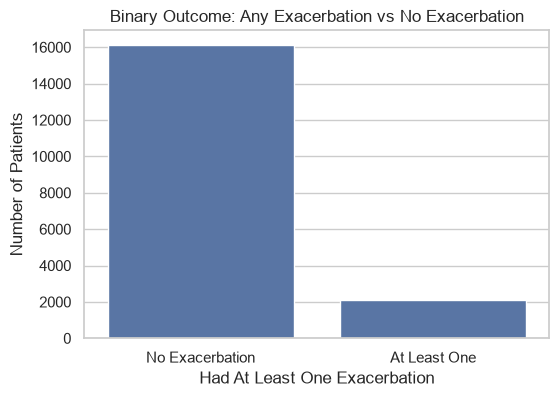

In [23]:
# Binary Outcome Count Plot
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="had_exacerbation"
)

plt.title("Binary Outcome: Any Exacerbation vs No Exacerbation")
plt.xlabel("Had At Least One Exacerbation")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Exacerbation", "At Least One"])
plt.show()

In [24]:
# lets make a binary Outcome Table
binary_outcome_summary = pd.DataFrame({
    "count": df["had_exacerbation"].value_counts().sort_index(),
    "percent": df["had_exacerbation"].value_counts(normalize=True).sort_index() * 100
})

binary_outcome_summary

,count,percent
had_exacerbation,,
0,16124,88.5205
1,2091,11.4795


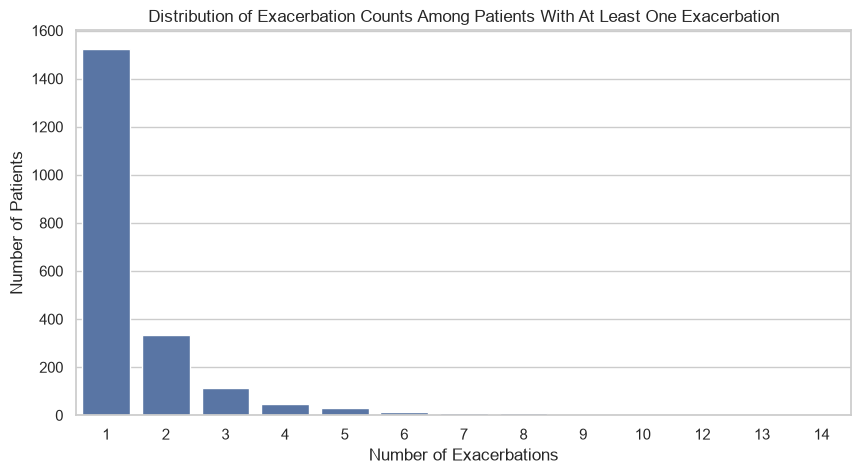

In [25]:
# Target Distribution Among Patients With Exacerbation Only
df_exac_only = df[df[target_col] > 0].copy()

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df_exac_only,
    x=target_col,
    order=sorted(df_exac_only[target_col].unique())
)

plt.title("Distribution of Exacerbation Counts Among Patients With At Least One Exacerbation")
plt.xlabel("Number of Exacerbations")
plt.ylabel("Number of Patients")
plt.show()

In [26]:
# Summary Among Patients With Exacerbation Only
df_exac_only[target_col].describe()

count   2091.0000
mean       1.5213
std        1.2024
min        1.0000
25%        1.0000
50%        1.0000
75%        2.0000
max       14.0000
Name: post_index_exacerbations365, dtype: float64



## Observation: Binary Outcome and Positive Exacerbation Group

The binary outcome summary shows that **16,124 patients**, or **88.52%**, had no exacerbation during the post-index year. Only **2,091 patients**, or **11.48%**, had at least one exacerbation.

This confirms that the binary version of the problem is highly imbalanced. If I later build a classification model, I should not rely only on accuracy because predicting the majority class may give a misleadingly high score. Later, I should evaluate classification models using metrics such as recall, precision, F1-score, ROC-AUC, and PR-AUC.

Among the patients who had at least one exacerbation, the average number of exacerbations was about **1.52**. The median was **1**, and the 75th percentile was **2**, meaning that most patients with exacerbations had only one or two events. However, the maximum value was **14**, showing that a small number of patients had much higher exacerbation counts. This suggests that even among the positive cases, the outcome is still right-skewed.

This suggests that there may be two related clinical prediction questions:

1. Can I predict whether a patient will have any exacerbation?
2. Among patients who have exacerbations, can I estimate how many exacerbations they may have?

For this project, I may eventually compare both approaches, but first I will continue exploring the predictor variables.

# Exploratory Data Analysis: Predictor Variables

After exploring the outcome variable, I now want to understand the predictor variables. This is important because machine learning models depend strongly on the quality and behavior of input features.

In this section, I will first examine:

1. Demographic variable: `index_age`
2. Treatment-related variables: `drug_s`, `adherence`, and `total_pre_index_cannisters_365`
3. Diagnosis indicator variables such as pneumonia, sinusitis, bronchitis, GERD, and rhinitis
4. Healthcare utilization and charge variables

My goal is not only to make plots, but also to understand what problems may appear during modeling. For example, some variables may be highly skewed, some may have very low event rates, and some may be strongly related to each other.

In [27]:
# Lets again define important column groups for EDA

id_col = "patid"
target_col = "post_index_exacerbations365"
binary_target_col = "had_exacerbation"

binary_predictor_cols = [
    "pneumonia",
    "sinusitis",
    "acute_bronchitis",
    "acute_laryngitis",
    "upper_respiratory_infection",
    "gerd",
    "rhinitis",
    "drug_s",
    "female"
]

discrete_predictor_cols = [
    "index_age",
    "previous_asthma_drugs",
    "total_pre_index_cannisters_365",
    "pre_asthma_days"
]

continuous_predictor_cols = [
    "adherence",
    "total_pre_index_charge",
    "pre_asthma_charge",
    "pre_asthma_pharma_charge",
    "log_charges",
    "log_asthma_charge"
]

## Age Distribution

I will start with `index_age`, which represents the patient's age on the day treatment started. Age is often an important predictor in healthcare data because disease severity, comorbidities, medication use, and treatment response may vary by age.

In [29]:
# Age summary
df["index_age"].describe()

count   18215.0000
mean       38.3046
std        15.2182
min        12.0000
25%        26.0000
50%        41.0000
75%        50.0000
max        65.0000
Name: index_age, dtype: float64

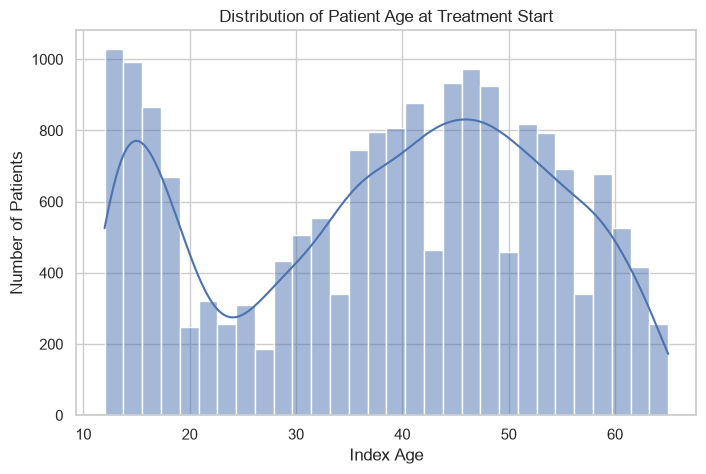

In [30]:
# Age histogram

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="index_age",
    bins=30,
    kde=True
)

plt.title("Distribution of Patient Age at Treatment Start")
plt.xlabel("Index Age")
plt.ylabel("Number of Patients")
plt.show()

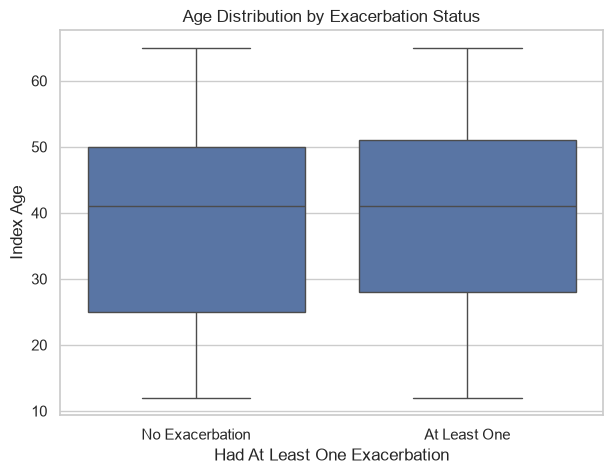

In [31]:
# Age by binary outcome
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="had_exacerbation",
    y="index_age"
)

plt.title("Age Distribution by Exacerbation Status")
plt.xlabel("Had At Least One Exacerbation")
plt.ylabel("Index Age")
plt.xticks([0, 1], ["No Exacerbation", "At Least One"])
plt.show()

In [32]:
# age summary table by outcome

df.groupby("had_exacerbation")["index_age"].describe()

,count,mean,std,min,25%,50%,75%,max
had_exacerbation,,,,,,,,
0,16124.0000,38.2093,15.2441,12.0000,25.0000,41.0000,50.0000,65.0000
1,2091.0000,39.0397,15.0003,12.0000,28.0000,41.0000,51.0000,65.0000


## Observation: Age

The `index_age` variable ranges from **12** to **65** years. The average age is about **38.30** years, and the median age is **41** years.

The histogram shows that the dataset includes both younger and older asthma patients, but the age range is limited to patients between adolescence and older adulthood.

When comparing age by exacerbation status, I wanted to check whether patients with at least one exacerbation appear older, younger, or similar in age compared with patients with no exacerbation. The data shows, patients with no exacerbation had an average age of about **38.21** years, while patients with at least one exacerbation had an average age of about **39.04** years. The median age was **41** years in both groups. This suggests that age alone may not strongly separate patients with and without exacerbations, although it may still provide some useful information when combined with other predictors.

## Drug Group Variable

The variable `drug_s` appears to represent the drug group assignment. It is coded as a binary variable:

- `0`: one treatment group
- `1`: another treatment group

At this stage, I do not know the exact drug names from the dataset column alone, so I will describe this variable as a treatment group indicator. I want to check how many patients are in each group and whether the outcome differs between the groups.

In [33]:
# Drug group counts

drug_summary = pd.DataFrame({
    "count": df["drug_s"].value_counts().sort_index(),
    "percent": df["drug_s"].value_counts(normalize=True).sort_index() * 100
})

drug_summary

,count,percent
drug_s,,
0,15275,83.8595
1,2940,16.1405


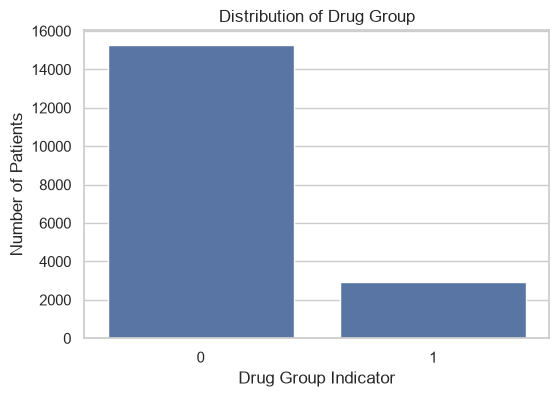

In [34]:
# drug group plotting
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="drug_s"
)

plt.title("Distribution of Drug Group")
plt.xlabel("Drug Group Indicator")
plt.ylabel("Number of Patients")
plt.show()

In [35]:
# outcome by drug group

df.groupby("drug_s")[target_col].describe()

,count,mean,std,min,25%,50%,75%,max
drug_s,,,,,,,,
0,15275.0000,0.1795,0.6404,0.0000,0.0000,0.0000,0.0000,14.0000
1,2940.0000,0.1493,0.5947,0.0000,0.0000,0.0000,0.0000,10.0000


In [36]:
# Binary outcome rate by drug group

drug_exacerbation_rate = df.groupby("drug_s")["had_exacerbation"].agg(
    count="count",
    exacerbation_rate="mean"
)

drug_exacerbation_rate["exacerbation_rate_percent"] = drug_exacerbation_rate["exacerbation_rate"] * 100

drug_exacerbation_rate

,count,exacerbation_rate,exacerbation_rate_percent
drug_s,,,
0,15275,0.1176,11.7643
1,2940,0.1000,10.0000


## Observation: Drug Group

The `drug_s` variable is imbalanced across treatment groups. Group 0 contains **15,275 patients** (**83.86%**), while group 1 contains **2,940 patients** (**16.14%**).

This means that most patients belong to one treatment group. If drug group is an important predictor, the imbalance in treatment group size should be considered during interpretation.

The average exacerbation count was slightly higher in drug group 0 than in drug group 1. Group 0 had a mean exacerbation count of about **0.18**, while group 1 had a mean of about **0.15**. When using the binary outcome, **11.76%** of patients in group 0 had at least one exacerbation, compared with **10.00%** in group 1.

This difference is small and should be interpreted carefully. It does not prove that one drug group is better than the other because this is only an exploratory comparison. Patients in the two drug groups may differ in baseline characteristics, asthma severity, adherence, prior healthcare use, or other factors. Later, machine learning models may help evaluate the importance of drug group while considering other predictors.

## Treatment-Related Variables: Adherence and Rescue Inhaler Use

Next, I will explore two treatment-related variables:

- `adherence`: A measure of how consistently the patient followed the medication/treatment regimen.
- `total_pre_index_cannisters_365`: Number of SABA rescue inhaler canisters used in the year before treatment start.

These variables may be important because adherence can affect treatment response, while higher rescue inhaler use before treatment may indicate more severe or poorly controlled asthma.

In [37]:
# Adherence summary
df["adherence"].describe()

count   18215.0000
mean        0.2496
std         0.2276
min         0.0054
25%         0.0845
50%         0.1689
75%         0.3379
max         1.0000
Name: adherence, dtype: float64

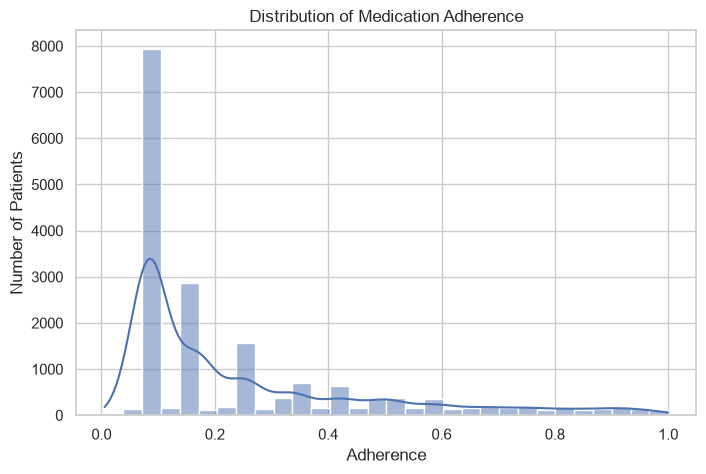

In [38]:
# Adherence histogram
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="adherence",
    bins=30,
    kde=True
)

plt.title("Distribution of Medication Adherence")
plt.xlabel("Adherence")
plt.ylabel("Number of Patients")
plt.show()

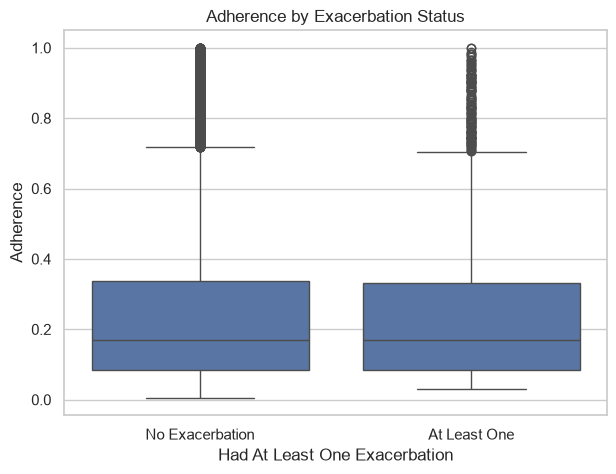

In [39]:
# Adherence by Binary Outcome
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="had_exacerbation",
    y="adherence"
)

plt.title("Adherence by Exacerbation Status")
plt.xlabel("Had At Least One Exacerbation")
plt.ylabel("Adherence")
plt.xticks([0, 1], ["No Exacerbation", "At Least One"])
plt.show()

In [40]:
# Adherence Summary by Outcome
df.groupby("had_exacerbation")["adherence"].describe()

,count,mean,std,min,25%,50%,75%,max
had_exacerbation,,,,,,,,
0,16124.0000,0.2503,0.2280,0.0054,0.0845,0.1689,0.3379,1.0000
1,2091.0000,0.2440,0.2242,0.0300,0.0845,0.1689,0.3324,1.0000


In [41]:
#Rescue Inhaler Canister Count Summary
df["total_pre_index_cannisters_365"].value_counts().sort_index()

total_pre_index_cannisters_365
0    7033
1    7906
2    3276
Name: count, dtype: int64

In [42]:
# Rescue Inhaler Use by Outcome
canister_outcome_summary = df.groupby("total_pre_index_cannisters_365")["had_exacerbation"].agg(
    count="count",
    exacerbation_rate="mean"
)

canister_outcome_summary["exacerbation_rate_percent"] = canister_outcome_summary["exacerbation_rate"] * 100

canister_outcome_summary

,count,exacerbation_rate,exacerbation_rate_percent
total_pre_index_cannisters_365,,,
0,7033,0.1112,11.1190
1,7906,0.1192,11.9150
2,3276,0.1120,11.2027


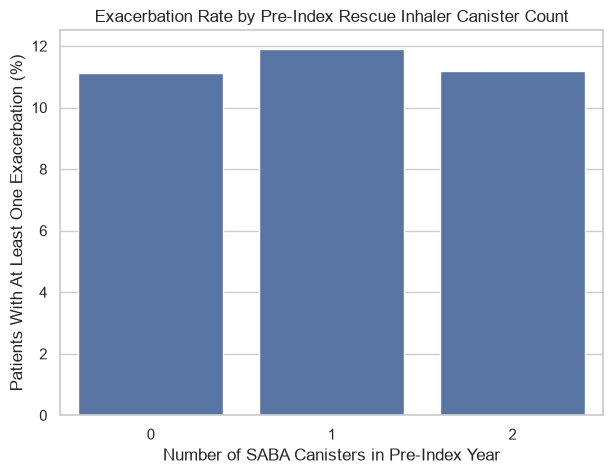

In [43]:
# Plotting Rescue Inhaler Use by Outcome Rate

plt.figure(figsize=(7, 5))

sns.barplot(
    data=canister_outcome_summary.reset_index(),
    x="total_pre_index_cannisters_365",
    y="exacerbation_rate_percent"
)

plt.title("Exacerbation Rate by Pre-Index Rescue Inhaler Canister Count")
plt.xlabel("Number of SABA Canisters in Pre-Index Year")
plt.ylabel("Patients With At Least One Exacerbation (%)")
plt.show()


## Observation: Adherence and Rescue Inhaler Use

The `adherence` variable ranges from **0.0054** to **1.0000**. The average adherence is about **0.25**, while the median is about **0.17**. This suggests that many patients have relatively low adherence values.

When comparing adherence by exacerbation status, the values are very similar between the two groups. Patients with no exacerbation had an average adherence of about **0.2503**, while patients with at least one exacerbation had an average adherence of about **0.2440**. The median adherence was the same in both groups at about **0.1689**.

This suggests that adherence alone may not strongly separate patients with and without exacerbations in this dataset. However, it may still be useful in combination with other variables during modeling.

The variable `total_pre_index_cannisters_365` has only three observed values: **0, 1, and 2**. This confirms that the variable is a truncated count variable, as mentioned in the dataset description. The patient counts were:

- **0 canisters:** 7,033 patients
- **1 canister:** 7,906 patients
- **2 canisters:** 3,276 patients

The exacerbation rates were also very similar across the three canister groups:

- **0 canisters:** 11.12%
- **1 canister:** 11.92%
- **2 canisters:** 11.20%

I originally expected that higher rescue inhaler use might be associated with higher post-index exacerbation risk, because SABA use can reflect worse baseline asthma control. However, in this dataset, the relationship is not obvious from this simple summary. One possible reason is that the canister variable is truncated to only 0, 1, and 2, which may limit its ability to capture more severe asthma patients. Another possibility is that other variables, such as prior asthma days, charge variables, diagnoses, or drug group, may explain more of the outcome variation.

## Diagnosis Indicator Variables

Next, I will explore the diagnosis indicator variables. These variables show whether a patient had certain respiratory or related diagnoses in the pre-index year.

The diagnosis variables are binary:

- `0`: diagnosis not recorded
- `1`: diagnosis recorded

The variables include pneumonia, sinusitis, acute bronchitis, acute laryngitis, upper respiratory infection, GERD, and rhinitis.

I want to check two things:

1. How common each diagnosis is in the dataset.
2. Whether patients with each diagnosis have a higher rate of post-index exacerbation.

In [44]:
#Diagnosis Columns
diagnosis_cols = [
    "pneumonia",
    "sinusitis",
    "acute_bronchitis",
    "acute_laryngitis",
    "upper_respiratory_infection",
    "gerd",
    "rhinitis"
]

diagnosis_cols

['pneumonia',
 'sinusitis',
 'acute_bronchitis',
 'acute_laryngitis',
 'upper_respiratory_infection',
 'gerd',
 'rhinitis']

In [45]:
# Diagnosis Prevalence Summary
diagnosis_prevalence = pd.DataFrame({
    "count_with_diagnosis": df[diagnosis_cols].sum(),
    "percent_with_diagnosis": df[diagnosis_cols].mean() * 100
}).sort_values("percent_with_diagnosis", ascending=False)

diagnosis_prevalence

,count_with_diagnosis,percent_with_diagnosis
rhinitis,7291,40.0274
sinusitis,5823,31.9682
acute_bronchitis,4745,26.0500
upper_respiratory_infection,4038,22.1685
gerd,1863,10.2278
pneumonia,915,5.0233
acute_laryngitis,307,1.6854


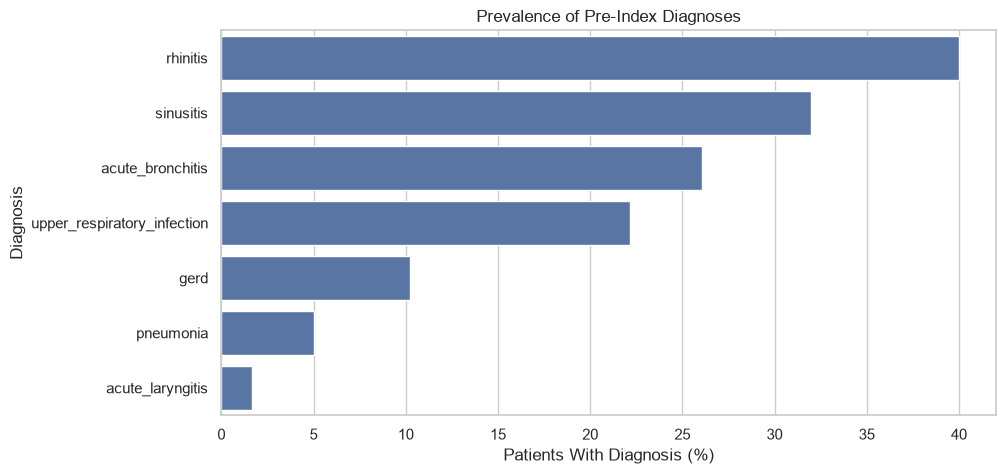

In [46]:
#Plotting Diagnosis Prevalence
plt.figure(figsize=(10, 5))

sns.barplot(
    data=diagnosis_prevalence.reset_index(),
    x="percent_with_diagnosis",
    y="index"
)

plt.title("Prevalence of Pre-Index Diagnoses")
plt.xlabel("Patients With Diagnosis (%)")
plt.ylabel("Diagnosis")
plt.show()

In [47]:
#xacerbation Rate by Diagnosis Status
# 
diagnosis_exac_rates = []

for col in diagnosis_cols:
    temp = df.groupby(col)["had_exacerbation"].agg(
        count="count",
        exacerbation_rate="mean"
    ).reset_index()
    
    temp["diagnosis"] = col
    temp["exacerbation_rate_percent"] = temp["exacerbation_rate"] * 100
    temp = temp.rename(columns={col: "diagnosis_status"})
    
    diagnosis_exac_rates.append(temp)

diagnosis_exac_rates = pd.concat(diagnosis_exac_rates, ignore_index=True)

diagnosis_exac_rates

,diagnosis_status,count,exacerbation_rate,diagnosis,exacerbation_rate_percent
0,0,17300,0.1140,pneumonia,11.3988
1,1,915,0.1301,pneumonia,13.0055
2,0,12392,0.1102,sinusitis,11.0232
3,1,5823,0.1245,sinusitis,12.4506
4,0,13470,0.1082,acute_bronchitis,10.8166
5,1,4745,0.1336,acute_bronchitis,13.3614
6,0,17908,0.1140,acute_laryngitis,11.4027
7,1,307,0.1596,acute_laryngitis,15.9609
8,0,14177,0.1119,upper_respiratory_infection,11.1871
9,1,4038,0.1251,upper_respiratory_infection,12.5062


In [50]:
# Lets Compare Exacerbation Rate for Diagnosis Present vs Absent
diagnosis_rate_comparison = diagnosis_exac_rates.pivot(
    index="diagnosis",
    columns="diagnosis_status",
    values="exacerbation_rate_percent"
).reset_index()

diagnosis_rate_comparison.columns = [
    "diagnosis",
    "exac_rate_without_diagnosis",
    "exac_rate_with_diagnosis"
]

diagnosis_rate_comparison["rate_difference"] = (
    diagnosis_rate_comparison["exac_rate_with_diagnosis"] -
    diagnosis_rate_comparison["exac_rate_without_diagnosis"]
)

diagnosis_rate_comparison = diagnosis_rate_comparison.sort_values(
    "rate_difference",
    ascending=False
)

diagnosis_rate_comparison["relative_change_percent"] = (
    diagnosis_rate_comparison["rate_difference"] /
    diagnosis_rate_comparison["exac_rate_without_diagnosis"]
) * 100

diagnosis_rate_comparison

,diagnosis,exac_rate_without_diagnosis,exac_rate_with_diagnosis,rate_difference,relative_change_percent
1,acute_laryngitis,11.4027,15.9609,4.5582,39.9745
0,acute_bronchitis,10.8166,13.3614,2.5448,23.5268
2,gerd,11.2219,13.7413,2.5194,22.4509
3,pneumonia,11.3988,13.0055,1.6066,14.0946
5,sinusitis,11.0232,12.4506,1.4274,12.9489
6,upper_respiratory_infection,11.1871,12.5062,1.3191,11.7908
4,rhinitis,12.0652,10.6021,-1.4631,-12.1263


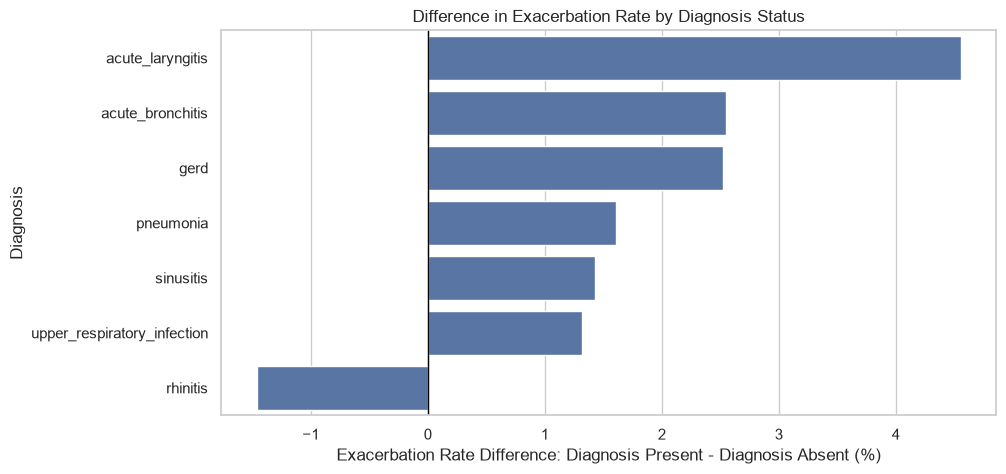

In [49]:
# Plotting Diagnosis-Associated Exacerbation Rate Difference

plt.figure(figsize=(10, 5))

sns.barplot(
    data=diagnosis_rate_comparison,
    x="rate_difference",
    y="diagnosis"
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Difference in Exacerbation Rate by Diagnosis Status")
plt.xlabel("Exacerbation Rate Difference: Diagnosis Present - Diagnosis Absent (%)")
plt.ylabel("Diagnosis")
plt.show()

## Observation: Diagnosis Variables

The diagnosis variables vary considerably in prevalence across the patient population. The most common diagnoses were:

- **Rhinitis (40.03%)**
- **Sinusitis (31.97%)**
- **Acute bronchitis (26.05%)**

The least common diagnosis was **acute laryngitis (1.69%)**, followed by pneumonia (5.02%).

I also compared the percentage of patients who experienced at least one post-index exacerbation between those with and without each diagnosis.

The largest increases in exacerbation rate were observed for:

| Diagnosis | Increase in Exacerbation Rate |
|-----------|------------------------------:|
| Acute laryngitis | +4.56 percentage points |
| Acute bronchitis | +2.54 percentage points |
| GERD | +2.52 percentage points |

Patients with these diagnoses appeared more likely to experience post-index exacerbations than patients without them.

One important caution is that **acute laryngitis was rare** in this dataset. Because only a small percentage of patients had this diagnosis, the observed increase in exacerbation rate may be less stable than the results for more common diagnoses such as acute bronchitis or GERD.

Interestingly, **rhinitis showed the opposite pattern**, with patients who had rhinitis having a slightly lower exacerbation rate than those without rhinitis (−1.46 percentage points). At this stage, I cannot conclude that rhinitis is protective. This unexpected result may be influenced by confounding factors, differences in patient characteristics, treatment patterns, or interactions with other variables. This will require further investigation during multivariable modeling.

I also calculated relative percentage change to support interpretation, but I will mainly discuss the absolute percentage-point differences because they are easier to interpret clinically.

Overall, these univariate comparisons suggest that several diagnosis variables may contain predictive information. However, they do not establish causal relationships because each variable has been examined independently without adjusting for other patient characteristics.


# Key Findings from Exploratory Data Analysis

Based on the exploratory analysis, I identified several observations that may influence later modeling:

1. The target variable is highly zero-inflated, with 88.52% of patients experiencing no post-index exacerbation.
2. The binary version of the outcome is therefore strongly imbalanced, so evaluation metrics beyond accuracy will be important.
3. The variable `previous_asthma_drugs` is constant across all patients and is unlikely to contribute to prediction.
4. Age shows only a small difference between patients with and without exacerbations when examined alone.
5. The treatment group (`drug_s`) shows only a modest difference in exacerbation rates, but further multivariable analysis is needed before drawing conclusions.
6. Medication adherence and truncated SABA canister count do not show strong univariate separation of the outcome.
7. Several diagnosis variables, particularly acute laryngitis, acute bronchitis, and GERD, show higher observed exacerbation rates and may become informative predictors.
8. The healthcare utilization and charge variables are highly skewed and will need careful handling during preprocessing and modeling.

These findings provide a better understanding of the dataset and help guide the preprocessing and machine learning modeling stages that follow.